Implement momentum-contrastve SSL
pretraining (§6b) on unlabeled snapshots

PHASE 2 – Momentum‑Contrastive SSL Pretraining (BYOL) with k‑NN + Silhouette

In [2]:
import os
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from torch.cuda.amp import autocast, GradScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# - CONFIGURATION -
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"
CHECKPOINT_DIR = os.path.join(DATA_DIR, "ssl_checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

HIDDEN_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 3
PROJECTION_DIM = 64
PREDICTION_DIM = 64
BATCH_SIZE = 2                     # small batch to save memory
GRAD_ACCUM_STEPS = 256             # effective batch size = 128*4
LEARNING_RATE = 5e-4               # stable learning rate
WEIGHT_DECAY = 1e-4
EPOCHS = 200
TAU_BASE = 0.99
TAU_MAX = 0.999
TAU_WARMUP_EPOCHS = 10
EDGE_DROPOUT_RATE = 0.2
FEATURE_MASK_RATE = 0.1
NODE_DROP_RATE = 0.1
SUBGRAPH_SAMPLE_RATE = 0.7
EVAL_INTERVAL = 1
EARLY_STOPPING_PATIENCE = 200
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# - LOAD GRAPHS -
def load_graphs(split):
    with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
        return pickle.load(f)

train_graphs = load_graphs('train')
val_graphs   = load_graphs('val')

# Keep a separate copy with labels for evaluation
probe_graphs = load_graphs('val')   # fresh copy with labels

# Unlabeled pool: train + val (remove labels from these)
unlabeled_graphs = train_graphs + val_graphs
print(f"Using {len(unlabeled_graphs)} graphs for SSL pretraining")

# Remove labels from unlabeled graphs
for g in unlabeled_graphs:
    for attr in ['y', 'edge_y', 'y_multihot', 'edge_attack_names']:
        if hasattr(g, attr):
            delattr(g, attr)

# Normalise features (using stats from Phase 1)
with open(os.path.join(DATA_DIR, "norm_stats.json"), 'r') as f:
    norm_stats = json.load(f)

node_mean = torch.tensor(norm_stats["node_mean"], dtype=torch.float)
node_std  = torch.tensor(norm_stats["node_std"], dtype=torch.float)
edge_mean = torch.tensor(norm_stats["edge_mean"], dtype=torch.float)
edge_std  = torch.tensor(norm_stats["edge_std"], dtype=torch.float)

def normalise_graphs(graphs):
    for g in graphs:
        g.x = (g.x - node_mean) / (node_std + 1e-8)
        g.x = torch.clamp(g.x, -10, 10)
        if g.edge_attr is not None and g.edge_attr.size(0) > 0:
            if g.edge_attr.dim() > 2:
                g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))
            g.edge_attr = (g.edge_attr - edge_mean) / (edge_std + 1e-8)
            g.edge_attr = torch.clamp(g.edge_attr, -10, 10)

normalise_graphs(unlabeled_graphs)
normalise_graphs(probe_graphs)

# Ensure edge_attr exists and is 2D
for g in unlabeled_graphs:
    if g.edge_attr is None or g.edge_attr.size(0) == 0:
        g.edge_attr = torch.zeros((g.edge_index.size(1), 0), dtype=torch.float)
    elif g.edge_attr.dim() > 2:
        g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))
for g in probe_graphs:
    if g.edge_attr is None or g.edge_attr.size(0) == 0:
        g.edge_attr = torch.zeros((g.edge_index.size(1), 0), dtype=torch.float)
    elif g.edge_attr.dim() > 2:
        g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))

# - AUGMENTATION HELPERS -
def apply_node_subset(data, keep_ratio):
    data = data.clone()
    num_nodes = data.num_nodes
    if num_nodes <= 1 or keep_ratio >= 1.0:
        return data
    keep_size = max(1, int(num_nodes * keep_ratio))
    perm = torch.randperm(num_nodes)[:keep_size]
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    mask[perm] = True
    src, dst = data.edge_index
    keep_edges = mask[src] & mask[dst]
    data.edge_index = data.edge_index[:, keep_edges]
    if data.edge_attr is not None and data.edge_attr.numel() > 0:
        if data.edge_attr.dim() > 2:
            data.edge_attr = data.edge_attr.view(-1, data.edge_attr.size(-1))
        data.edge_attr = data.edge_attr[keep_edges]
    data.x = data.x[mask]
    node_idx = torch.zeros(num_nodes, dtype=torch.long)
    node_idx[mask] = torch.arange(mask.sum())
    data.edge_index = node_idx[data.edge_index]
    return data

def augment_batch(batch, edge_drop_rate=0.2, feat_mask_rate=0.1,
                  node_drop_rate=0.1, subgraph_rate=0.8):
    data_list = batch.to_data_list()
    new_data_list = []
    for data in data_list:
        # 1. Edge dropout (manual)
        if edge_drop_rate > 0 and data.edge_index.size(1) > 0:
            num_edges = data.edge_index.size(1)
            mask = torch.rand(num_edges, device=data.edge_index.device) > edge_drop_rate
            if mask.sum() > 0:
                data.edge_index = data.edge_index[:, mask]
                if data.edge_attr is not None and data.edge_attr.size(0) > 0:
                    if data.edge_attr.dim() > 2:
                        data.edge_attr = data.edge_attr.view(-1, data.edge_attr.size(-1))
                    data.edge_attr = data.edge_attr[mask]
            else:
                data.edge_index = data.edge_index[:, :1]
                if data.edge_attr is not None and data.edge_attr.size(0) > 0:
                    data.edge_attr = data.edge_attr[:1]

        # 2. Node dropout
        if node_drop_rate > 0 and data.num_nodes > 1:
            data = apply_node_subset(data, 1.0 - node_drop_rate)

        # 3. Subgraph sampling
        if subgraph_rate < 1.0 and data.num_nodes > 1:
            data = apply_node_subset(data, subgraph_rate)

        # 4. Feature masking
        if feat_mask_rate > 0:
            mask = torch.rand_like(data.x) < feat_mask_rate
            data.x[mask] = 0.0
            if data.edge_attr is not None and data.edge_attr.size(0) > 0:
                mask_edge = torch.rand_like(data.edge_attr) < feat_mask_rate
                data.edge_attr[mask_edge] = 0.0

        # Safety: empty graph
        if data.num_nodes == 0 or data.edge_index.size(1) == 0:
            data.x = torch.zeros(1, data.x.size(1), dtype=data.x.dtype)
            data.edge_index = torch.zeros(2, 0, dtype=torch.long)
            data.edge_attr = torch.zeros(0, data.edge_attr.size(1), dtype=data.edge_attr.dtype)

        new_data_list.append(data)
    return Batch.from_data_list(new_data_list)

# - GAT ENCODER -
class GATEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_heads, num_layers, edge_dim):
        super(GATEncoder, self).__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels, heads=num_heads,
                                  edge_dim=edge_dim, concat=True, dropout=0.0))
        self.bns.append(nn.BatchNorm1d(hidden_channels * num_heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * num_heads, hidden_channels, heads=num_heads,
                                      edge_dim=edge_dim, concat=True, dropout=0.0))
            self.bns.append(nn.BatchNorm1d(hidden_channels * num_heads))
        self.convs.append(GATConv(hidden_channels * num_heads, hidden_channels, heads=1,
                                  edge_dim=edge_dim, concat=False, dropout=0.0))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.edge_dim = edge_dim

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        for i, conv in enumerate(self.convs):
            if edge_attr is not None and self.edge_dim > 0:
                x = conv(x, edge_index, edge_attr=edge_attr)
            else:
                x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
        x = global_mean_pool(x, batch)
        return x

# - SSL MODEL (Online + Target) -
class SSLModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_heads, num_layers, edge_dim,
                 projection_dim, prediction_dim):
        super(SSLModel, self).__init__()
        self.encoder = GATEncoder(in_channels, hidden_channels, num_heads, num_layers, edge_dim)
        self.projector = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, projection_dim)
        )
        self.predictor = nn.Sequential(
            nn.Linear(projection_dim, prediction_dim),
            nn.BatchNorm1d(prediction_dim),
            nn.ReLU(),
            nn.Linear(prediction_dim, projection_dim)
        )

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        h = self.encoder(x, edge_index, edge_attr, batch)
        z = self.projector(h)
        p = self.predictor(z)
        return h, z, p

def update_target_network(target_model, source_model, tau):
    for target_param, source_param in zip(target_model.parameters(), source_model.parameters()):
        target_param.data.mul_(tau).add_(source_param.data, alpha=1 - tau)
from sklearn.metrics import classification_report
from collections import defaultdict

# Get per-class labels (you need to store attack names per graph)
# If you only have binary labels, you'll need to temporarily re-attach edge_attack_names
# during evaluation. Assuming you have 'edge_attack_names' in probe_graphs:

def per_class_knn_f1(encoder, probe_graphs, device, k=5):
    encoder.eval()
    X, y_names = [], []  # y_names = list of attack names per graph
    with torch.no_grad():
        for g in probe_graphs:
            if not hasattr(g, 'edge_attack_names'):
                continue
            g = g.to(device)
            batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
            emb = encoder(g.x, g.edge_index, g.edge_attr, batch)
            X.append(emb.cpu().numpy().flatten())
            # Store the first attack name (or 'Benign')
            attack_names = [n for n in g.edge_attack_names if n != 'Benign']
            y_names.append(attack_names[0] if attack_names else 'Benign')
    
    X = np.vstack(X)
    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)
    
    # k-NN on the entire set
    knn = KNeighborsClassifier(n_neighbors=min(k, len(X)-1))
    knn.fit(X_scaled, y_names)
    preds = knn.predict(X_scaled)
    
    # Per-class F1
    report = classification_report(y_names, preds, output_dict=True)
    return report
# - k‑NN + SILHOUETTE EVALUATION -
def knn_silhouette_eval(encoder, probe_graphs, device, k=5, test_size=0.5):
    encoder.eval()
    X, y = [], []
    with torch.no_grad():
        for g in probe_graphs:
            if not hasattr(g, 'y') or g.y is None:
                continue
            g = g.to(device)
            batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
            emb = encoder(g.x, g.edge_index, g.edge_attr, batch)
            X.append(emb.cpu().numpy().flatten())
            y.append(g.y.item())
    if len(y) == 0 or len(np.unique(y)) < 2:
        return 0.0, 0.0

    X = np.vstack(X)
    y = np.array(y)

    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=min(k, len(X_train)-1))
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)

    if len(np.unique(y)) >= 2 and len(y) > 2:
        sil = silhouette_score(X_scaled, y, metric='cosine')
    else:
        sil = 0.0

    return f1, sil


Using 1132 graphs for SSL pretraining


In [2]:
import gc
import json
import torch
from torch.cuda.amp import GradScaler

#  Checkpoint & Results paths 
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "ssl_checkpoint.pth")
RESULTS_PATH = os.path.join(CHECKPOINT_DIR, "ssl_results.json")

#  Functions to save/load checkpoint 
def save_checkpoint(epoch, model, target_model, optimizer, scheduler, scaler,
                    best_knn_f1, best_val_loss, patience_counter):
    checkpoint = {
        'epoch': epoch,
        'online_model_state_dict': model.state_dict(),
        'target_model_state_dict': target_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_knn_f1': best_knn_f1,
        'best_val_loss': best_val_loss,
        'patience_counter': patience_counter,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

def load_checkpoint(model, target_model, optimizer, scheduler, scaler):
    if os.path.exists(CHECKPOINT_PATH):
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint['online_model_state_dict'])
        target_model.load_state_dict(checkpoint['target_model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        epoch = checkpoint['epoch'] + 1
        best_knn_f1 = checkpoint['best_knn_f1']
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint['patience_counter']
        print(f"Resuming from epoch {epoch}")
        return epoch, best_knn_f1, best_val_loss, patience_counter
    else:
        return 1, -1, float('inf'), 0

#  Results logging 
def load_results():
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH, 'r') as f:
            return json.load(f)
    else:
        return []

def save_results(results):
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=4)

#  PREPARE TRAINING 
sample_graph = unlabeled_graphs[0]
node_dim = sample_graph.x.size(1)
edge_dim = sample_graph.edge_attr.size(1) if sample_graph.edge_attr is not None else 0

online_model = SSLModel(node_dim, HIDDEN_DIM, NUM_HEADS, NUM_LAYERS, edge_dim,
                        PROJECTION_DIM, PREDICTION_DIM).to(DEVICE)
target_model = SSLModel(node_dim, HIDDEN_DIM, NUM_HEADS, NUM_LAYERS, edge_dim,
                        PROJECTION_DIM, PREDICTION_DIM).to(DEVICE)
target_model.load_state_dict(online_model.state_dict())
for param in target_model.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(online_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = GradScaler()
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
#  Create unlabeled validation loader (for SSL loss) 
val_unlabeled = []
for g in val_graphs:
    h = g.clone()
    for attr in ['y', 'edge_y', 'y_multihot', 'edge_attack_names']:
        if hasattr(h, attr):
            delattr(h, attr)
    val_unlabeled.append(h)

val_loader = DataLoader(val_unlabeled, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=lambda b: Batch.from_data_list(b), pin_memory=False)
train_loader = DataLoader(unlabeled_graphs, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=lambda b: Batch.from_data_list(b), pin_memory=False)

probe_graphs_cpu = probe_graphs

#  Load checkpoint and results if they exist 
start_epoch, best_knn_f1, best_val_loss, patience_counter = load_checkpoint(
    online_model, target_model, optimizer, scheduler, scaler
)

results = load_results()
# If results already contain entries for epochs >= start_epoch, we should trim to avoid duplicates.
# We'll only keep entries with epoch < start_epoch.
if results:
    results = [r for r in results if r['epoch'] < start_epoch]
    print(f"Loaded {len(results)} previous results.")

#  TRAINING LOOP 
for epoch in range(start_epoch, EPOCHS + 1):
    tau = TAU_BASE + (TAU_MAX - TAU_BASE) * min(1.0, epoch / TAU_WARMUP_EPOCHS)

    online_model.train()
    total_loss = 0
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)):
        # Augment – catch OOM for individual batch
        try:
            batch1 = augment_batch(batch, EDGE_DROPOUT_RATE, FEATURE_MASK_RATE,
                                   NODE_DROP_RATE, SUBGRAPH_SAMPLE_RATE).to(DEVICE)
            batch2 = augment_batch(batch, EDGE_DROPOUT_RATE, FEATURE_MASK_RATE,
                                   NODE_DROP_RATE, SUBGRAPH_SAMPLE_RATE).to(DEVICE)
        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"OOM in batch {batch_idx}. Skipping this batch.")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

        with autocast():
            _, z1, p1 = online_model(batch1.x, batch1.edge_index, batch1.edge_attr, batch1.batch)
            _, z2, p2 = online_model(batch2.x, batch2.edge_index, batch2.edge_attr, batch2.batch)
            with torch.no_grad():
                _, z1_target, _ = target_model(batch1.x, batch1.edge_index, batch1.edge_attr, batch1.batch)
                _, z2_target, _ = target_model(batch2.x, batch2.edge_index, batch2.edge_attr, batch2.batch)
            p1 = F.normalize(p1, dim=-1)
            p2 = F.normalize(p2, dim=-1)
            z1_target = F.normalize(z1_target, dim=-1)
            z2_target = F.normalize(z2_target, dim=-1)

            loss1 = 2 - 2 * (p1 * z2_target).sum(dim=-1).mean()
            loss2 = 2 - 2 * (p2 * z1_target).sum(dim=-1).mean()
            loss = (loss1 + loss2) / 2
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or (batch_idx + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(online_model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            update_target_network(target_model, online_model, tau)

        total_loss += loss.item() * GRAD_ACCUM_STEPS * batch.num_graphs

        # Free memory
        del batch1, batch2, loss, loss1, loss2, z1, z2, p1, p2, z1_target, z2_target
        torch.cuda.empty_cache()

    avg_train_loss = total_loss / len(train_loader.dataset)
    scheduler.step()

    #  Validation SSL loss 
    online_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch1 = augment_batch(batch, EDGE_DROPOUT_RATE, FEATURE_MASK_RATE,
                                   NODE_DROP_RATE, SUBGRAPH_SAMPLE_RATE).to(DEVICE)
            batch2 = augment_batch(batch, EDGE_DROPOUT_RATE, FEATURE_MASK_RATE,
                                   NODE_DROP_RATE, SUBGRAPH_SAMPLE_RATE).to(DEVICE)
            _, z1, p1 = online_model(batch1.x, batch1.edge_index, batch1.edge_attr, batch1.batch)
            _, z2, p2 = online_model(batch2.x, batch2.edge_index, batch2.edge_attr, batch2.batch)
            with torch.no_grad():
                _, z1_target, _ = target_model(batch1.x, batch1.edge_index, batch1.edge_attr, batch1.batch)
                _, z2_target, _ = target_model(batch2.x, batch2.edge_index, batch2.edge_attr, batch2.batch)
            p1 = F.normalize(p1, dim=-1)
            p2 = F.normalize(p2, dim=-1)
            z1_target = F.normalize(z1_target, dim=-1)
            z2_target = F.normalize(z2_target, dim=-1)

            loss1 = 2 - 2 * (p1 * z2_target).sum(dim=-1).mean()
            loss2 = 2 - 2 * (p2 * z1_target).sum(dim=-1).mean()
            loss = (loss1 + loss2) / 2
            val_loss += loss.item() * batch.num_graphs

            del batch1, batch2, loss, loss1, loss2, z1, z2, p1, p2, z1_target, z2_target
            torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader.dataset)

    #  k‑NN & Silhouette every EVAL_INTERVAL epochs 
    knn_f1 = 0.0
    sil = 0.0
    if epoch % EVAL_INTERVAL == 0 or epoch == 1:
        knn_f1, sil = knn_silhouette_eval(online_model.encoder, probe_graphs_cpu, DEVICE, k=5, test_size=0.5)

    current_lr = scheduler.get_last_lr()[0]

    #  Log results 
    epoch_result = {
        'epoch': epoch,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'knn_f1': knn_f1,
        'silhouette': sil,
        'tau': tau,
        'learning_rate': current_lr
    }
    results.append(epoch_result)
    save_results(results)

    #  Print progress 
    print(f"Epoch {epoch:03d} | LR: {current_lr:.6f} | SSL Loss: {avg_train_loss:.4f} | Val SSL Loss: {avg_val_loss:.4f} | k‑NN F1: {knn_f1:.4f} | Silhouette: {sil:.4f} | Tau: {tau:.4f} ")

    #  Save best model based on k‑NN F1 
    if knn_f1 > best_knn_f1:
        best_knn_f1 = knn_f1
        torch.save(online_model.encoder.state_dict(), os.path.join(CHECKPOINT_DIR, "ssl_encoder_best.pth"))
        torch.save(online_model.state_dict(), os.path.join(CHECKPOINT_DIR, "ssl_full_online_best.pth"))
        print(f"New best model saved (k‑NN F1: {best_knn_f1:.4f} at epoch {epoch})")

    #  Early stopping based on validation SSL loss 
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement in validation SSL loss for {EARLY_STOPPING_PATIENCE} epochs)")
            break

    #  Save checkpoint after each epoch 
    save_checkpoint(epoch, online_model, target_model, optimizer, scheduler, scaler,
                    best_knn_f1, best_val_loss, patience_counter)

    #  Force memory cleanup at the end of each epoch 
    gc.collect()
    torch.cuda.empty_cache()
    if epoch % 10 == 0:
        print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
        print(f"GPU memory cached: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

#  Clean up checkpoint if training completes 
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)

print(f"\n SSL pretraining complete. Best k‑NN F1: {best_knn_f1:.4f}")
print(f"Encoder saved to: {os.path.join(CHECKPOINT_DIR, 'ssl_encoder_best.pth')}")
print(f"Results saved to: {RESULTS_PATH}")


Loaded 0 previous results.


Epoch 001 | LR: 0.000450 | SSL Loss: 2.1005 | Val SSL Loss: 2.1836 | k‑NN F1: 0.9274 | Silhouette: 0.3151 | Tau: 0.9909 
New best model saved (k‑NN F1: 0.9274 at epoch 1)


Epoch 002 | LR: 0.000405 | SSL Loss: 1.9720 | Val SSL Loss: 1.9913 | k‑NN F1: 0.9683 | Silhouette: 0.3186 | Tau: 0.9918 
New best model saved (k‑NN F1: 0.9683 at epoch 2)


Epoch 003 | LR: 0.000365 | SSL Loss: 1.8806 | Val SSL Loss: 1.9377 | k‑NN F1: 0.9683 | Silhouette: 0.3115 | Tau: 0.9927 


Epoch 004 | LR: 0.000328 | SSL Loss: 1.8337 | Val SSL Loss: 1.9933 | k‑NN F1: 0.9274 | Silhouette: 0.3257 | Tau: 0.9936 


...

Epoch 196 | LR: 0.000000 | SSL Loss: 1.2691 | Val SSL Loss: 1.4727 | k‑NN F1: 0.9683 | Silhouette: 0.3207 | Tau: 0.9990 


Epoch 197 | LR: 0.000000 | SSL Loss: 1.2707 | Val SSL Loss: 1.4774 | k‑NN F1: 0.9683 | Silhouette: 0.3459 | Tau: 0.9990 


Epoch 198 | LR: 0.000000 | SSL Loss: 1.2722 | Val SSL Loss: 1.5681 | k‑NN F1: 0.9683 | Silhouette: 0.3427 | Tau: 0.9990 


Epoch 199 | LR: 0.000000 | SSL Loss: 1.2759 | Val SSL Loss: 1.4627 | k‑NN F1: 0.9683 | Silhouette: 0.3235 | Tau: 0.9990 


Epoch 200 | LR: 0.000000 | SSL Loss: 1.2744 | Val SSL Loss: 1.4898 | k‑NN F1: 0.9683 | Silhouette: 0.3328 | Tau: 0.9990 
GPU memory allocated: 1.35 GB
GPU memory cached: 1.70 GB

 SSL pretraining complete. Best k‑NN F1: 0.9790
Encoder saved to: GothamDataset2025/processed_features/gotham_graphs\ssl_checkpoints\ssl_encoder_best.pth
Results saved to: GothamDataset2025/processed_features/gotham_graphs\ssl_checkpoints\ssl_results.json


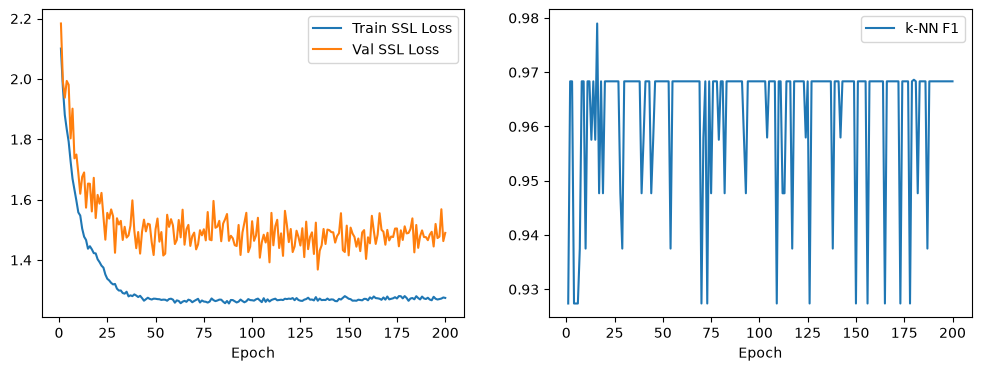

In [3]:
import json
import matplotlib.pyplot as plt

with open("GothamDataset2025/processed_features/gotham_graphs/ssl_checkpoints/ssl_results.json", 'r') as f:
    data = json.load(f)

epochs = [d['epoch'] for d in data] 
train_loss = [d['train_loss'] for d in data]
val_loss = [d['val_loss'] for d in data]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label='Train SSL Loss')
plt.plot(epochs, val_loss, label='Val SSL Loss')
plt.legend()
plt.xlabel('Epoch')

# Grab data only for epochs where 'knn_f1' is not 0
epochs = [d['epoch'] for d in data] 
train_loss = [d['train_loss'] for d in data]
val_loss = [d['val_loss'] for d in data]
knn_f1 = [d['knn_f1'] for d in data]

plt.subplot(1,2,2)
plt.plot(epochs, knn_f1, label='k-NN F1')
plt.legend()
plt.xlabel('Epoch')
plt.show()

In [9]:
# ============================================================================
# SSL ENCODER EVALUATION – k‑NN, Silhouette, Cosine Similarities, t‑SNE
# ============================================================================
import os
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn import GATConv
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#  CONFIG 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = "GothamDataset2025/processed_features/gotham_graphs"
CHECKPOINT_DIR = os.path.join(DATA_DIR, "ssl_checkpoints")
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "ssl_encoder_best.pth")

HIDDEN_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 3

#  DEFINE ENCODER (must match training) 
class GATEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_heads, num_layers, edge_dim):
        super(GATEncoder, self).__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels, heads=num_heads,
                                  edge_dim=edge_dim, concat=True, dropout=0.0))
        self.bns.append(nn.BatchNorm1d(hidden_channels * num_heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * num_heads, hidden_channels, heads=num_heads,
                                      edge_dim=edge_dim, concat=True, dropout=0.0))
            self.bns.append(nn.BatchNorm1d(hidden_channels * num_heads))
        self.convs.append(GATConv(hidden_channels * num_heads, hidden_channels, heads=1,
                                  edge_dim=edge_dim, concat=False, dropout=0.0))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.edge_dim = edge_dim

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        for i, conv in enumerate(self.convs):
            if edge_attr is not None and self.edge_dim > 0:
                x = conv(x, edge_index, edge_attr=edge_attr)
            else:
                x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
        x = global_mean_pool(x, batch)
        return x

#  LOAD GRAPHS (validation set with labels) 
def load_graphs(split):
    with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
        return pickle.load(f)

val_graphs = load_graphs('val')
print(f"Loaded {len(val_graphs)} validation graphs.")

# Normalise features (using stats from Phase 1)
with open(os.path.join(DATA_DIR, "norm_stats.json"), 'r') as f:
    norm_stats = json.load(f)

node_mean = torch.tensor(norm_stats["node_mean"], dtype=torch.float)
node_std  = torch.tensor(norm_stats["node_std"], dtype=torch.float)
edge_mean = torch.tensor(norm_stats["edge_mean"], dtype=torch.float)
edge_std  = torch.tensor(norm_stats["edge_std"], dtype=torch.float)

def normalise_graphs(graphs):
    for g in graphs:
        g.x = (g.x - node_mean) / (node_std + 1e-8)
        g.x = torch.clamp(g.x, -10, 10)
        if g.edge_attr is not None and g.edge_attr.size(0) > 0:
            if g.edge_attr.dim() > 2:
                g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))
            g.edge_attr = (g.edge_attr - edge_mean) / (edge_std + 1e-8)
            g.edge_attr = torch.clamp(g.edge_attr, -10, 10)

normalise_graphs(val_graphs)

# Ensure edge_attr exists and is 2D
for g in val_graphs:
    if g.edge_attr is None or g.edge_attr.size(0) == 0:
        g.edge_attr = torch.zeros((g.edge_index.size(1), 0), dtype=torch.float)
    elif g.edge_attr.dim() > 2:
        g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))

#  LOAD ENCODER 
sample_graph = val_graphs[0]
node_dim = sample_graph.x.size(1)
edge_dim = sample_graph.edge_attr.size(1) if sample_graph.edge_attr is not None else 0

encoder = GATEncoder(node_dim, HIDDEN_DIM, NUM_HEADS, NUM_LAYERS, edge_dim).to(DEVICE)
encoder.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
encoder.eval()
print("Encoder loaded successfully.")

#  COMPUTE EMBEDDINGS 
embeddings = []
labels = []
with torch.no_grad():
    for g in val_graphs:
        if not hasattr(g, 'y') or g.y is None:
            continue
        g = g.to(DEVICE)
        batch = torch.zeros(g.num_nodes, dtype=torch.long, device=DEVICE)
        emb = encoder(g.x, g.edge_index, g.edge_attr, batch)
        embeddings.append(emb.cpu().numpy().flatten())
        labels.append(g.y.item())
        del g

embeddings = np.vstack(embeddings)
labels = np.array(labels)
print(f"Computed embeddings for {len(labels)} graphs.")
print(f"Benign: {np.sum(labels == 0)}, Attack: {np.sum(labels == 1)}")

if len(np.unique(labels)) < 2:
    print("Only one class in validation set – cannot compute clustering metrics.")
else:
    # Standardise embeddings
    scaler = StandardScaler().fit(embeddings)
    emb_scaled = scaler.transform(embeddings)

    #  k‑NN F1 (on a split of validation) 
    X_train, X_test, y_train, y_test = train_test_split(
        emb_scaled, labels, test_size=0.3, random_state=42, stratify=labels
    )
    knn = KNeighborsClassifier(n_neighbors=min(5, len(X_train)-1))
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    knn_f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    print(f"k‑NN macro F1 (on validation split): {knn_f1:.4f}")

    #  Silhouette score 
    sil = silhouette_score(emb_scaled, labels, metric='cosine')
    print(f"Silhouette Score (cosine): {sil:.4f}")

    #  Cosine similarities 
    # Normalise embeddings to unit length
    emb_norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    sim_matrix = emb_norm @ emb_norm.T

    benign_idx = np.where(labels == 0)[0]
    attack_idx = np.where(labels == 1)[0]

    if len(benign_idx) > 1:
        sim_benign = sim_matrix[np.ix_(benign_idx, benign_idx)]
        np.fill_diagonal(sim_benign, np.nan)
        mean_sim_benign = np.nanmean(sim_benign)
    else:
        mean_sim_benign = np.nan

    if len(attack_idx) > 1:
        sim_attack = sim_matrix[np.ix_(attack_idx, attack_idx)]
        np.fill_diagonal(sim_attack, np.nan)
        mean_sim_attack = np.nanmean(sim_attack)
    else:
        mean_sim_attack = np.nan

    sim_across = sim_matrix[np.ix_(benign_idx, attack_idx)]
    mean_sim_across = np.mean(sim_across) if sim_across.size > 0 else np.nan

    print("\nAverage cosine similarity:")
    print(f"  Within benign:    {mean_sim_benign:.4f}")
    print(f"  Within attack:    {mean_sim_attack:.4f}")
    print(f"  Across classes:   {mean_sim_across:.4f}")

print("\n Evaluation complete.")

Loaded 200 validation graphs.
Encoder loaded successfully.
Computed embeddings for 200 graphs.
Benign: 79, Attack: 121
k‑NN macro F1 (on validation split): 0.9825
Silhouette Score (cosine): 0.3215

Average cosine similarity:
  Within benign:    0.9729
  Within attack:    0.7962
  Across classes:   0.8533

 Evaluation complete.


Computing 2D t-SNE...


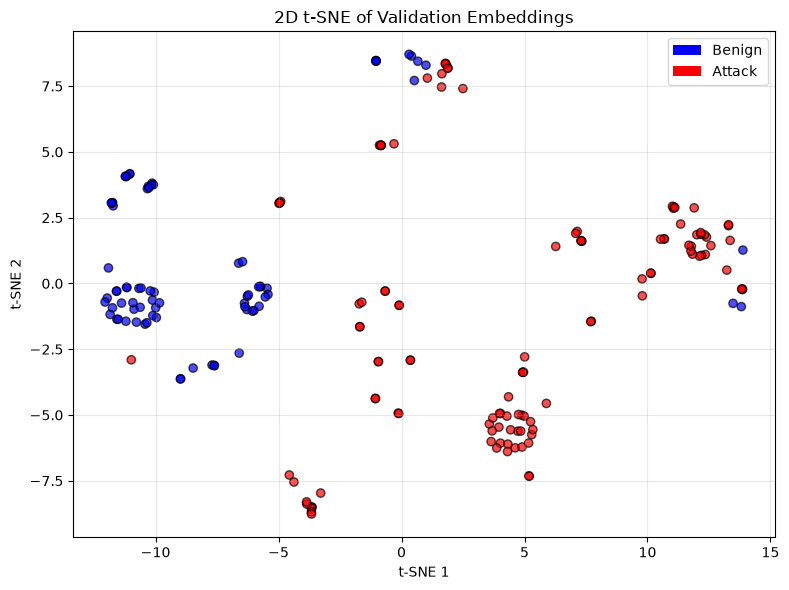

Computing 3D t-SNE...


Computing confusion matrix...


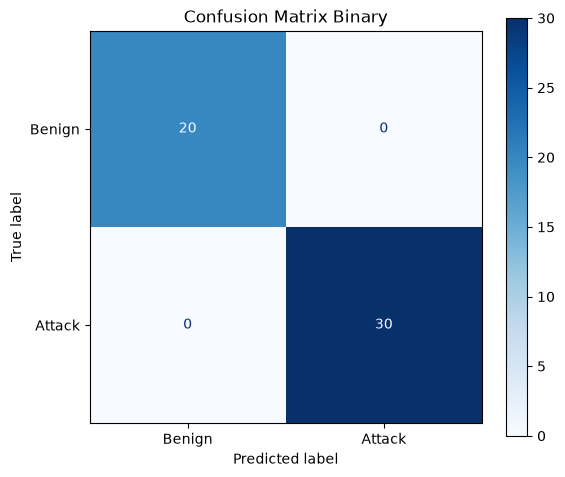

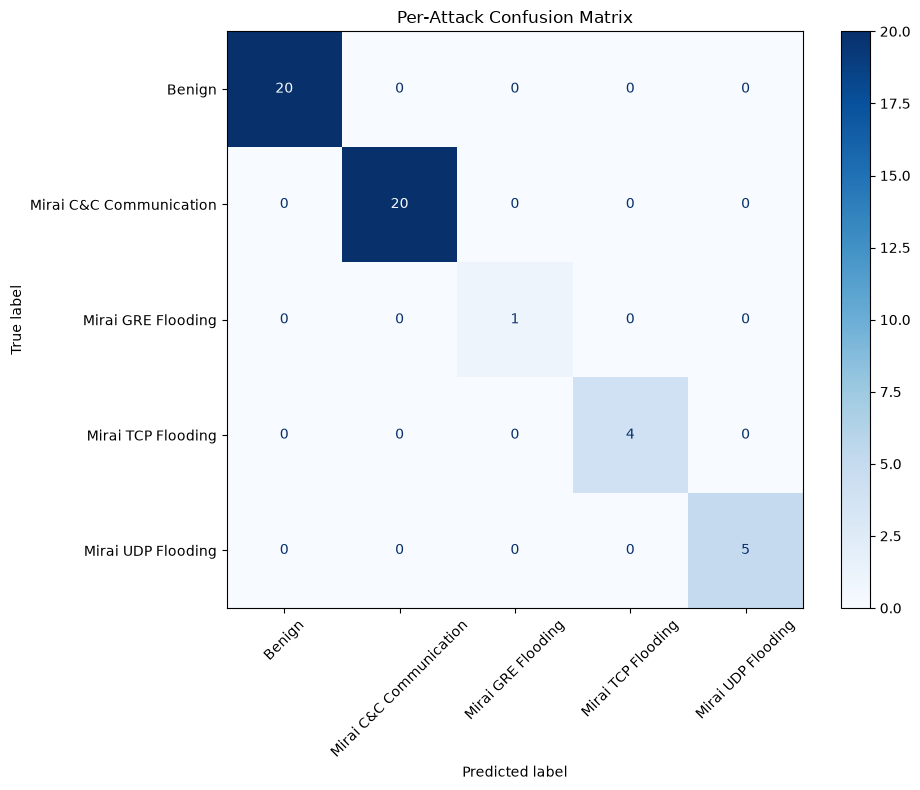

In [12]:
# =====================================================================
# MULTI‑ANGLE VISUALISATION CELL (with Confusion Matrix)
# (run this after computing embeddings and labels)
# =====================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import os
import numpy as np

#  Standardise embeddings (already done in your script) 
# emb_scaled and labels are assumed to exist from earlier code.

#  1. 2D t-SNE (static) 
print("Computing 2D t-SNE...")
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=min(30, len(labels)-1))
emb_2d = tsne_2d.fit_transform(emb_scaled)

plt.figure(figsize=(8, 6))
colors = ['blue' if l == 0 else 'red' for l in labels]
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, alpha=0.7, edgecolors='k')
plt.title("2D t‑SNE of Validation Embeddings")
plt.xlabel("t‑SNE 1"); plt.ylabel("t‑SNE 2")
from matplotlib.patches import Patch
plt.legend(handles=[Patch(facecolor='blue', label='Benign'),
                    Patch(facecolor='red', label='Attack')])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "tsne_2d.png"), dpi=300, bbox_inches='tight')
plt.show()

# ---- 3D t-SNE (interactive) with smaller markers ----
print("Computing 3D t-SNE...")
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=min(30, len(labels)-1))
emb_3d = tsne_3d.fit_transform(emb_scaled)

df_3d = pd.DataFrame(emb_3d, columns=['x', 'y', 'z'])
df_3d['class'] = ['Benign' if l==0 else 'Attack' for l in labels]

fig = px.scatter_3d(
    df_3d, x='x', y='y', z='z', color='class',
    title="3D t‑SNE (interactive – drag to rotate)",
    color_discrete_map={'Benign':'blue', 'Attack':'red'},
    opacity=0.7                # <-- adds transparency
)
# Manually set marker size to a smaller value (default ~6-8)
fig.update_traces(marker=dict(size=6))

fig.show()
fig.write_html(os.path.join(DATA_DIR, "tsne_3d.html"))


#  5. Confusion Matrix (static + interactive) 
print("Computing confusion matrix...")
X_train, X_test, y_train, y_test = train_test_split(
    emb_scaled, labels, random_state=42, stratify=labels
)

# Find the best k (optional) but use k=5 as in your SSL eval
k = min(5, len(np.unique(y_train)) - 1)  # fallback if only one class
if k < 1:
    k = 1
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

#  Binary confusion matrix 
cm = confusion_matrix(y_test, y_pred)
class_names = ['Benign', 'Attack']

# Static Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix Binary")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "confusion_matrix_binary.png"), dpi=300, bbox_inches='tight')
plt.show()

try:
    if 'probe_graphs' in locals() and len(probe_graphs) == len(labels):
        attack_names_all = []
        for g in probe_graphs:
            if hasattr(g, 'edge_attack_names') and g.edge_attack_names:
                # get the first attack name (exclude 'Benign' if present)
                names = [n for n in g.edge_attack_names if n != 'Benign']
                attack_names_all.append(names[0] if names else 'Benign')
            else:
                attack_names_all.append('Benign')
        indices = np.arange(len(labels))
        _, test_indices, _, _ = train_test_split(
            indices, labels, random_state=42, stratify=labels
        )
        y_names_test = [attack_names_all[i] for i in test_indices]
        X_train_names, X_test_names, y_train_names, y_test_names = train_test_split(
            emb_scaled, attack_names_all, random_state=42, stratify=labels
        )
        knn_names = KNeighborsClassifier(n_neighbors=k)
        knn_names.fit(X_train_names, y_train_names)
        y_pred_names = knn_names.predict(X_test_names)
        
        # Compute confusion matrix for attack names
        unique_names = sorted(set(y_test_names))
        cm_names = confusion_matrix(y_test_names, y_pred_names, labels=unique_names)
        # Display
        fig, ax = plt.subplots(figsize=(10, 8))
        disp_names = ConfusionMatrixDisplay(confusion_matrix=cm_names, display_labels=unique_names)
        disp_names.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
        plt.title("Per‑Attack Confusion Matrix")
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_DIR, "confusion_matrix_per_attack.png"), dpi=300, bbox_inches='tight')
        plt.show()
        
except Exception as e:
    print(f"Could not generate per‑attack confusion matrix: {e}")